In [ ]:
# Generative AI -powered Stock Market Trend Preiciton
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Reshape,LeakyReLU , BatchNormalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
from google.colab import drive
drive.mount("/content/drive",force_remount=True)

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/stock_data.csv')

In [ ]:
df.head()

,Date,Open,High,Low,Close,Volume
0,01-03-2006,39.69,41.22,38.79,40.91,24232729
1,01-04-2006,41.22,41.90,40.77,40.97,20553479
2,01-05-2006,40.93,41.73,40.85,41.53,12829610
3,01-06-2006,42.88,43.57,42.80,43.21,29422828
4,01-09-2006,43.10,43.66,42.82,43.42,16268338


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   object 
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 141.6+ KB


In [ ]:
plt.figure(figsize=(100,100))
plt.plot(df['Date'],df['Close'])
plt.title("Stock Prices")
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()

In [ ]:
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [ ]:
scaled_data

array([[0.4995311 ],
       [0.5004689 ],
       [0.50922163],
       ...,
       [0.95514223],
       [0.95139106],
       [0.95185996]])

In [ ]:
# data prepration
def prepare_data(data,time_steps=100):
  X,Y=[],[]
  for i in range(len(data)-time_steps-1):
    X.append(data[i:(i+time_steps),0])
    Y.append(data[i+time_steps,0])
    return np.array(X),np.array(Y)

In [ ]:
time_step=60
X_train,Y_train=prepare_data(scaled_data,time_step)
X_train= np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))

In [ ]:
X_train

array([[[0.4995311 ],
        [0.5004689 ],
        [0.50922163],
        [0.53547984],
        [0.53876211],
        [0.53188496],
        [0.51453579],
        [0.49921851],
        [0.48374492],
        [0.4870272 ],
        [0.40997187],
        [0.39668646],
        [0.38746483],
        [0.39418568],
        [0.4051266 ],
        [0.39918725],
        [0.40981557],
        [0.40856518],
        [0.40793998],
        [0.39746796],
        [0.40715849],
        [0.39543607],
        [0.38433886],
        [0.37464833],
        [0.37621132],
        [0.37589872],
        [0.36808378],
        [0.36824008],
        [0.36089403],
        [0.37152235],
        [0.37621132],
        [0.37199125],
        [0.37214755],
        [0.36636449],
        [0.3783995 ],
        [0.3782432 ],
        [0.37605502],
        [0.37183495],
        [0.36120663],
        [0.36308221],
        [0.35557987],
        [0.3516724 ],
        [0.35354798],
        [0.3513598 ],
        [0.34448265],
        [0

In [ ]:
generator=Sequential([
    Dense(128,input_dim=100),
    LeakyReLU(alpha=0.2),
    BatchNormalization(momentum=0.8),
    Dense(256),
    LeakyReLU(alpha=0.2),
    BatchNormalization(momentum=0.8),
    Dense(512),
    LeakyReLU(alpha=0.2),
    BatchNormalization(momentum=0.8),
    Dense(time_step),
    Reshape((time_step,1))
    ])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
discriminator=Sequential([
    Flatten(input_shape=(time_step,1)),
    Dense(512),
    LeakyReLU(alpha=0.2),
    Dense(256),
    LeakyReLU(alpha=0.2),
    Dense(1,activation='sigmoid')
])
discriminator.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# build a combined model
discriminator.trainable=False
gan=Sequential([generator,discriminator])
gan.compile(loss='binary_crossentropy',optimizer='adam')

In [ ]:
# training our model
def train_gan(X_train,epochs,batch_size=128,save_interval=50):
  half_batch=int(batch_size/2)

  for epoch in range(epochs):
    idx=np.random.randint(0,X_train.shape[0],half_batch)
    real_data=X_train[idx]
    noise=np.random.normal(0,1,(half_batch,100))
    generated_data=generator.predict(noise)
    d_loss_real=discriminator.train_on_batch(real_data,np.ones((half_batch,1)))
    d_loss_fake=discriminator.train_on_batch(generated_data,np.zeros((half_batch,1)))
    d_loss=0.5*np.add(d_loss_real,d_loss_fake)
    noise=np.random.normal(0,1,(batch_size,100))
    valid_y=np.array([1]*batch_size)
    g_loss=gan.train_on_batch(noise,valid_y)
    if epoch % save_interval ==0:
          print(f"{epoch} [D loss: {d_loss[0]},D accuracy: {100*d_loss[1]}] [G loss: {g_loss}]")
train_gan(X_train,1000,batch_size=32,save_interval=200)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.7438806295394897,D accuracy: 0.0] [G loss: 0.5823966264724731]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


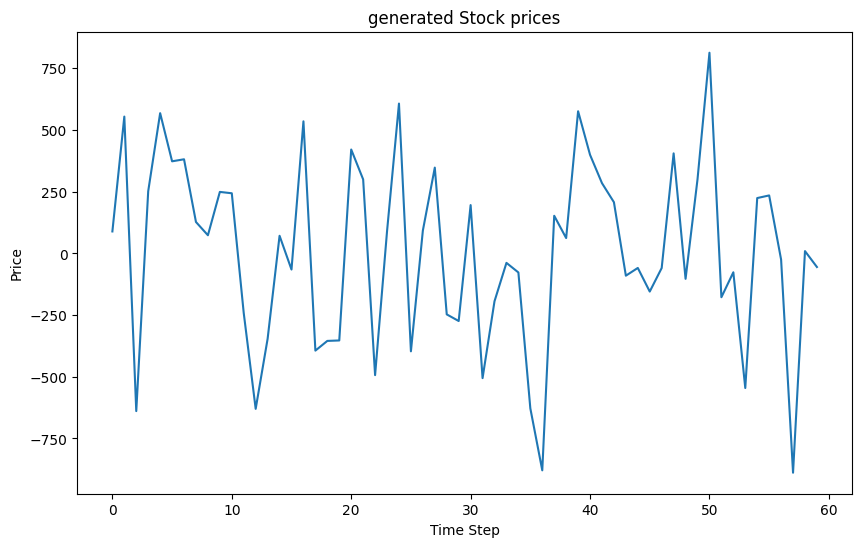

In [ ]:
noise =np.random.normal(0,1,(1,100))
generated_stock_prices=generator.predict(noise)
generated_stock_prices=scaler.inverse_transform(generated_stock_prices.reshape(-1,1))
plt.figure(figsize=(10,6))
plt.plot(range(len(generated_stock_prices)),generated_stock_prices)
plt.title('generated Stock prices')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.show()

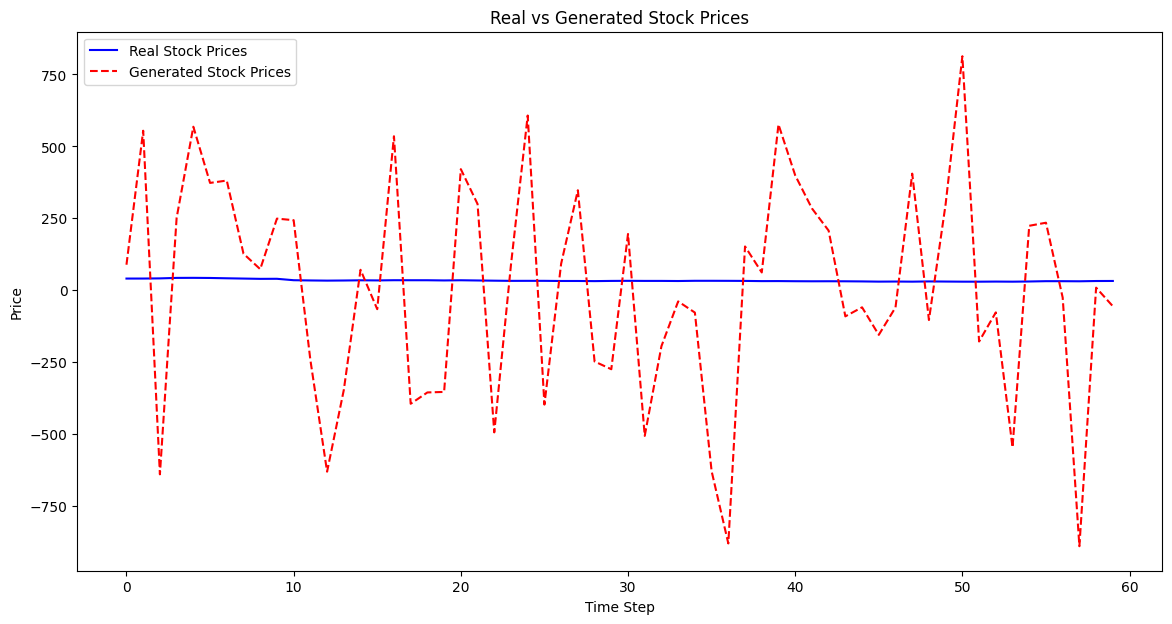

In [ ]:
real_stock_prices=scaler.inverse_transform(X_train[0].reshape(-1,1))
# Plotting the real stock prices
plt.figure(figsize=(14,7))
plt.plot(real_stock_prices,color='blue',label='Real Stock Prices')
plt.plot(generated_stock_prices,color='red',linestyle='--',label='Generated Stock Prices')
plt.title('Real vs Generated Stock Prices')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
mse=mean_squared_error(real_stock_prices,generated_stock_prices)

In [ ]:
print(f'Mean Square Error:{mse}')

Mean Square Error:141647.75177742227
